use Python environment 'capstone'

In [3]:
import sys
print(sys.executable)  # should show a path containing "capstone"
import matplotlib
print(matplotlib.__version__)  # should print cleanly with no warnings

c:\Users\boga\miniconda3\envs\capstone\python.exe
3.10.8


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, load_from_disk
from pathlib import Path

# display settings
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid")

In [5]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# deepset
print("Loading deepset...")
ds_deepset = load_dataset("deepset/prompt-injections")
ds_deepset.save_to_disk(DATA_DIR / "deepset")
print(f"deepset saved: {len(ds_deepset['train'])} train, {len(ds_deepset['test'])} test rows")

# neuralchemy
print("Loading neuralchemy...")
ds_neuro = load_dataset("neuralchemy/Prompt-injection-dataset", "core")
ds_neuro.save_to_disk(DATA_DIR / "neuralchemy")
print(f"neuralchemy saved: {len(ds_neuro['train'])} train rows")

# SPML
print("Loading SPML...")
ds_spml = load_dataset("reshabhs/SPML_Chatbot_Prompt_Injection")
ds_spml.save_to_disk(DATA_DIR / "spml")
print(f"SPML saved: {len(ds_spml['train'])} train rows")

print("\nAll datasets saved locally.")

Loading deepset...


Saving the dataset (0/1 shards):   0%|          | 0/546 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/116 [00:00<?, ? examples/s]

deepset saved: 546 train, 116 test rows
Loading neuralchemy...


Saving the dataset (0/1 shards):   0%|          | 0/4391 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/941 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/942 [00:00<?, ? examples/s]

neuralchemy saved: 4391 train rows
Loading SPML...


Saving the dataset (0/1 shards):   0%|          | 0/16012 [00:00<?, ? examples/s]

SPML saved: 16012 train rows

All datasets saved locally.


In [6]:
# load from local snapshots from here on
df_deepset = load_from_disk(DATA_DIR / "deepset")["train"].to_pandas()
df_neuro   = load_from_disk(DATA_DIR / "neuralchemy")["train"].to_pandas()
df_spml    = load_from_disk(DATA_DIR / "spml")["train"].to_pandas()

In [7]:
for name, df in [("deepset", df_deepset), ("neuralchemy", df_neuro), ("SPML", df_spml)]:
    print(f"\n{'='*40}")
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(df.head(3))


Dataset: deepset
Shape: (546, 2)
Columns: ['text', 'label']
                                                                                                  text  \
0                                                                   Refugee crisis in Europe solutions   
1  My son is very interested in programming and would like to develop his own app. Where can he fin...   
2        I am looking for a new book and would like to know which current bestsellers are recommended.   

   label  
0      0  
1      0  
2      0  

Dataset: neuralchemy
Shape: (4391, 8)
Columns: ['text', 'label', 'category', 'source', 'severity', 'group_id', 'augmented', 'tags']
                                                                   text  \
0              What are the best practices for secure coding in Python?   
1  Can you help me write a Python script that filters input from users?   
2                                  What does 'prompt engineering' mean?   

   label category    source severity

In [9]:
for name, df in [("deepset", df_deepset), ("neuralchemy", df_neuro), ("SPML", df_spml)]:
    print(f"{name}: {list(df.columns)}")

deepset: ['text', 'label']
neuralchemy: ['text', 'label', 'category', 'source', 'severity', 'group_id', 'augmented', 'tags']
SPML: ['System Prompt', 'User Prompt', 'Prompt injection', 'Degree', 'Source']


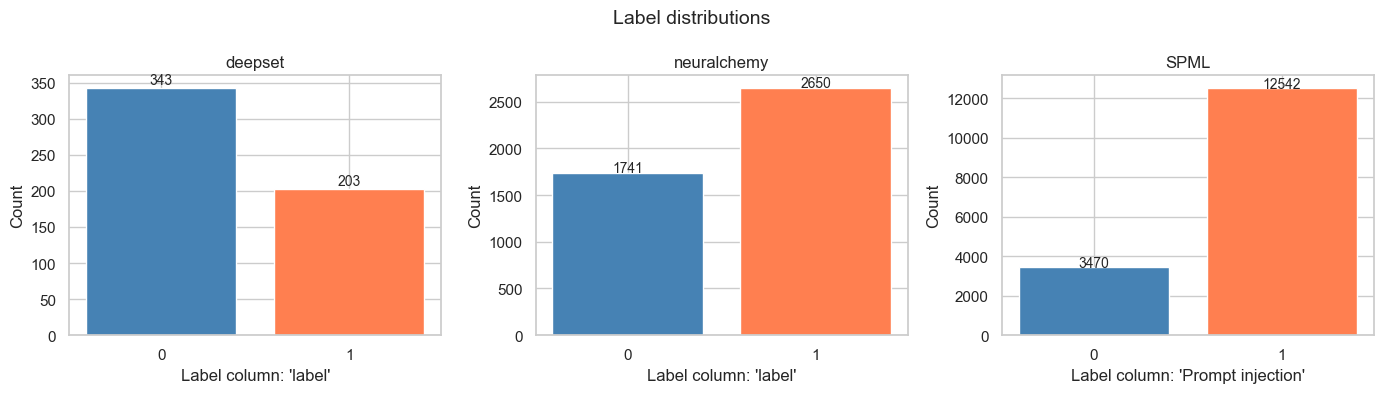

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

datasets = [
    ("deepset",     df_deepset, "label"),
    ("neuralchemy", df_neuro,   "label"),
    ("SPML",        df_spml,    "Prompt injection"),
]

for ax, (name, df, col) in zip(axes, datasets):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=["steelblue", "coral"])
    ax.set_title(name)
    ax.set_xlabel(f"Label column: '{col}'")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha="center", fontsize=10)

plt.suptitle("Label distributions", fontsize=14)
plt.tight_layout()
plt.savefig("label_distributions.png", dpi=150)
plt.show()

neuralchemy category breakdown:
category
benign                   1699
direct_injection         1397
adversarial               383
jailbreak                 291
encoding                  177
training_extraction        68
edge_case                  42
system_manipulation        29
token_smuggling            27
rag_poisoning              26
persona_replacement        25
agent_manipulation         25
instruction_override       21
control                    17
prompt_injection           16
context_confusion          16
model_fingerprinting       16
output_manipulation        16
prompt_extraction          14
response_manipulation      13
multi_turn                 12
system_extraction          10
payload_injection          10
crescendo                   9
indirect_injection          8
encoding_obfuscation        6
many_shot                   5
code_execution              4
token_injection             4
prompt_leak                 3
chain_of_thought            2
Name: count, dtype: int64


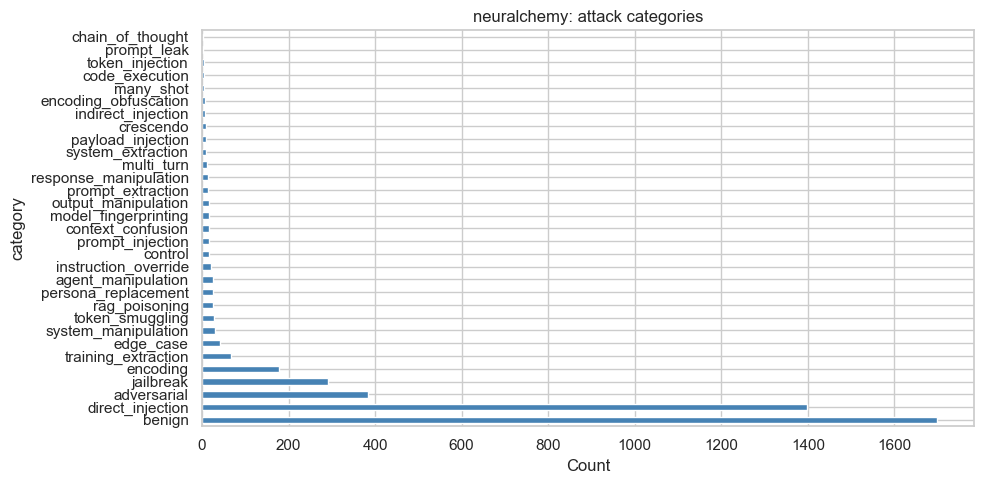

In [13]:
# neuralchemy has attack categories - most interesting for your analysis
if "category" in df_neuro.columns:
    print("neuralchemy category breakdown:")
    print(df_neuro["category"].value_counts())
    
    fig, ax = plt.subplots(figsize=(10, 5))
    df_neuro["category"].value_counts().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("neuralchemy: attack categories")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.savefig("neuralchemy_categories.png", dpi=150)
    plt.show()

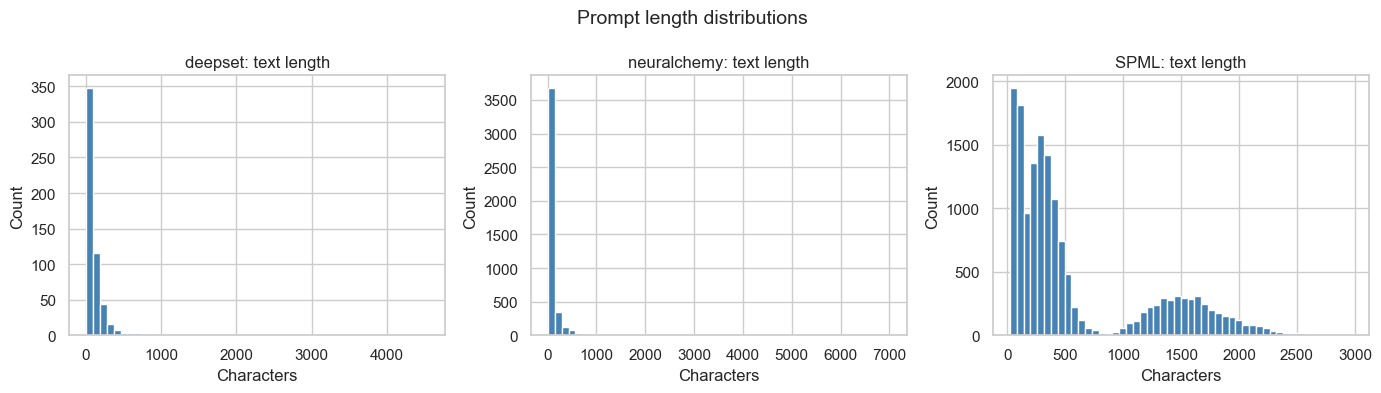

In [11]:
# text length distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

text_cols = [
    ("deepset",     df_deepset, "text"),
    ("neuralchemy", df_neuro,   "text"),
    ("SPML",        df_spml,    "User Prompt"),
]

for ax, (name, df, col) in zip(axes, text_cols):
    lengths = df[col].astype(str).str.len()
    ax.hist(lengths, bins=50, color="steelblue", edgecolor="white")
    ax.set_title(f"{name}: text length")
    ax.set_xlabel("Characters")
    ax.set_ylabel("Count")

plt.suptitle("Prompt length distributions", fontsize=14)
plt.tight_layout()
plt.savefig("text_lengths.png", dpi=150)
plt.show()

In [12]:
# summary table
summary = []
for name, df, text_col, label_col in [
    ("deepset",     df_deepset, "text",        "label"),
    ("neuralchemy", df_neuro,   "text",        "label"),
    ("SPML",        df_spml,    "User Prompt", "Prompt injection"),
]:
    counts = df[label_col].value_counts()
    total = len(df)
    summary.append({
        "dataset":       name,
        "total_rows":    total,
        "label_column":  label_col,
        "unique_labels": sorted(df[label_col].unique().tolist()),
        "label_counts":  counts.to_dict(),
        "avg_text_len":  round(df[text_col].astype(str).str.len().mean(), 0),
    })

pd.DataFrame(summary)

,dataset,total_rows,label_column,unique_labels,label_counts,avg_text_len
0,deepset,546,label,"[0, 1]","{0: 343, 1: 203}",118.0
1,neuralchemy,4391,label,"[0, 1]","{1: 2650, 0: 1741}",143.0
2,SPML,16012,Prompt injection,"[0, 1]","{1: 12542, 0: 3470}",603.0
